In [1]:
# !pip install bayesian-optimization lightgbm imblearn optbinning probatus 

In [2]:
!pip install bayesian-optimization

In [3]:
import os
# os.chdir('../')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import re #regular expression

import matplotlib.pyplot as plt #For plotting graphs
import matplotlib.ticker as mtick
#plt.style.use('ggplot')
#include plots in the notebook
%matplotlib inline 
import seaborn as sns #For plotting graphs
#sns.set(style='darkgrid')
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder #for creating dummy variables out of categorical variables
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, \
confusion_matrix, mean_squared_error, balanced_accuracy_score,roc_curve
import matplotlib.pyplot as plt

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV,RandomizedSearchCV
from scipy.stats import chi2_contingency

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Undersampling and Oversampling Libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss, CondensedNearestNeighbour,TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.metrics import classification_report_imbalanced

from sklearn.preprocessing import OrdinalEncoder

from optbinning import OptimalBinning

# Recursive Feature Elimination
import warnings
# warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
warnings.filterwarnings('ignore')
from probatus.feature_elimination import ShapRFECV

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

#utilities
import collections

import warnings
warnings.filterwarnings("ignore")

# from LGBMBayesianOptimization import bayes_parameter_opt_lgb
from functions import *

import openpyxl

pd.set_option('display.max_colwidth', None)

import shap
# print the JS visualization code to the notebook
shap.initjs()

(CVXPY) Feb 18 05:36:17 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Version of ortools (9.4.1874) is too old. Expected >= 9.5.0.')
(CVXPY) Feb 18 05:36:17 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Version of ortools (9.4.1874) is too old. Expected >= 9.7.0.')


In [4]:
run_date_str = '20250131'  # queries will pull data up to 1 day prior to run_date_str
s3_output = f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}'
# df = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}/processed_train.parquet') 

df_train = pd.read_parquet(os.path.join(s3_output, 'train_xs.parquet'))
df_val =pd.read_parquet(os.path.join(s3_output, 'test_xs.parquet'))

df_loans =pd.read_parquet(os.path.join(s3_output, 'loans.parquet'))

In [5]:
print(df_train.shape)
print(df_val.shape)
print(df_loans.shape)

(10303121, 55)
(1714060, 55)
(54785, 25)


In [6]:
df_train = pd.merge(df_train,df_loans[['rid','created_date','entity_identifier','loan_id',"horizon", 
    "major_version","minor_version", "pd", "base_model_pd", "calibrated_pd_270", "calibrated_pd_360",'fpf']],left_on=['rid','dt'],right_on=['rid','created_date'], how='inner')

In [7]:
df_train.shape

(30955, 66)

In [8]:
df_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 30955 entries, 0 to 30954
Data columns (total 66 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   rid                                30955 non-null  int64         
 1   dt                                 30955 non-null  datetime64[ns]
 2   label_60                           30955 non-null  float64       
 3   flag_ge50_3d_over_7d               30955 non-null  int64         
 4   state                              30955 non-null  object        
 5   parent_market_segment              30955 non-null  int64         
 6   restaurant_type                    30955 non-null  object        
 7   account_restaurant_category        30955 non-null  int64         
 8   days_delta_first_obs               30955 non-null  int64         
 9   first_loan_date                    30892 non-null  datetime64[ns]
 10  days_with_toast                   

In [9]:
df_val = pd.merge(df_val,df_loans[['rid','created_date','entity_identifier','loan_id',"horizon", 
    "major_version","minor_version", "pd", "base_model_pd", "calibrated_pd_270", "calibrated_pd_360",'fpf']],left_on=['rid','dt'],right_on=['rid','created_date'], how='inner')

In [10]:
df_val.shape

(8298, 66)

In [11]:
#Keep valid states
list_us_state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD",
    "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]
df_train = df_train[df_train['state'].isin(list_us_state_codes)]
df_val = df_val[df_val['state'].isin(list_us_state_codes)]

In [12]:
print(df_train.shape)
print(df_val.shape)

(30710, 66)
(8216, 66)


In [13]:
df_train = df_train[df_train['days_with_toast']>=90]
df_val = df_val[df_val['days_with_toast']>=90]

In [14]:
print('Not Default vs Default\n',df_train.label_60.value_counts(dropna=False))
var = round(df_train.label_60.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    30373
1.0      309
Name: label_60, dtype: int64
The event rate is 1.01%


In [15]:
print('Not Default vs Default\n',df_val.label_60.value_counts(dropna=False))
var = round(df_val.label_60.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    8138
1.0      69
Name: label_60, dtype: int64
The event rate is 0.84%


In [16]:
df_train['dt'].min()

Timestamp('2022-01-03 00:00:00')

In [17]:
print('Not Default vs Default\n',df_train.fpf.value_counts(dropna=False))
var = round(df_train.fpf.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    30562
1.0      120
Name: fpf, dtype: int64
The event rate is 0.39%


In [18]:
print('Not Default vs Default\n',df_val.fpf.value_counts(dropna=False))
var = round(df_val.fpf.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    8181
1.0      26
Name: fpf, dtype: int64
The event rate is 0.32%


# Create seasonality features

In [19]:
df_train['day_of_year'] = df_train['dt'].dt.dayofyear
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_val['day_of_year'] = df_val['dt'].dt.dayofyear
df_val['month'] = df_val['dt'].dt.month
df_val['quarter'] = df_val['dt'].dt.quarter

# Train/Test Split

In [20]:
data = df_train.copy()
y = data.fpf
remove_list = ['fpf']
stratify_class = data[['fpf', 'state']]
X = data.drop(columns=remove_list)

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=.25, random_state=42)
X_train.shape, X_test.shape

((23011, 68), (7671, 68))

In [21]:
df_train = pd.merge(X_train,y_train,left_index=True,right_index=True,how='inner')
df_test = pd.merge(X_test,y_test,left_index=True,right_index=True,how='inner')

In [22]:
print('Not Default vs Default\n',df_train.fpf.value_counts(dropna=False))
var = round(df_train.fpf.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    22921
1.0       90
Name: fpf, dtype: int64
The event rate is 0.39%


In [23]:
print('Not Default vs Default\n',df_test.fpf.value_counts(dropna=False))
var = round(df_test.fpf.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    7641
1.0      30
Name: fpf, dtype: int64
The event rate is 0.39%


In [24]:
print('Not Default vs Default\n',df_val.fpf.value_counts(dropna=False))
var = round(df_val.fpf.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    8181
1.0      26
Name: fpf, dtype: int64
The event rate is 0.32%


# LGBM variable list preparation

In [25]:
feature_list = [
    "rid", "dt", "label_60", 'fpf', "flag_ge50_3d_over_7d", 'base_model_pd','calibrated_pd_270','calibrated_pd_360',
    "state", "parent_market_segment", "restaurant_type", "account_restaurant_category", "days_delta_first_obs",
    "days_with_toast", "months_with_toast",
    "has_oo_mod", "has_gc_mod",
    "noprocessing_last_90d", "gpv_mean_90d", "gpv_mean_28d", "gpv_median_28d",
    "gpv_cv_90d", "log_gpv_std_90d", "gpv_median_28d_mean_90d_diff",
    "gpv_median_28d_median_84d_diff", "gpv_median_28d_28ddiff",
    "gpv_median_28d_84ddiff", "gpv_per_hour_median_28d",
    "gpv_per_hour_median_28d_28ddiff", "days_no_gpv_90d",
    "days_no_gpv_28d", "days_no_gpv_28d_28ddiff",
    "tx_hours_mean_14d", "tx_hours_median_14d", "tx_hours_median_28d",
    "tx_hours_median_28d_28ddiff", "live_online_ordering_module_count",
    "live_saas_mrr", "live_saas_module_count", "live_gift_card_module_count",
    "total_no_of_orders_30d",
    "median_no_of_orders_180d", "std_orders_180d", "gmv_sum_30d",
    "total_size_orders_90", "GMV_90D_Percent_Change",
    "GMV_YoY_90D_Percent_Change", "gpv_mean_365d",
    "gpv_mean_180d", "gpv_cv_180d", "gpv_median_84d",
    "gpv_median_180d", "gpv_median_28d_median_180d_diff",
    "gpv_per_hour", "noprocessing_last_180d"
]

In [26]:
#create a dictionary with feature name and type "numerical" or "categorical". This will be used by the optbinning process
# feature_list = list(X.columns)
remove_list = ["rid", "dt", "label_60", 'fpf', "flag_ge50_3d_over_7d",'entity_identifier','base_model_pd','calibrated_pd_270','calibrated_pd_360',]
feature_list = [x for x in feature_list if x not in remove_list]
feature_dict = {}
for feature in feature_list:
    feature_dict[feature] = str(X[feature].dtype)

for feature in feature_dict.keys():
    # print(feature, feature_type[feature])
    if feature_dict[feature] == 'float64' or feature_dict[feature] == 'int64' or feature_dict[feature] == 'int32':
        feature_dict[feature] = 'numerical'
    if feature_dict[feature] == 'object':
        feature_dict[feature] = 'categorical' 
    if feature in ['day_of_year','month','quarter','week_of_year']:
        feature_dict[feature] = 'categorical' 
#Sort by having categorical features at the top.
feature_dict=dict(sorted(feature_dict.items(), key=lambda item: item[1]))

In [27]:
feature_dict

{'state': 'categorical',
 'restaurant_type': 'categorical',
 'parent_market_segment': 'numerical',
 'account_restaurant_category': 'numerical',
 'days_delta_first_obs': 'numerical',
 'days_with_toast': 'numerical',
 'months_with_toast': 'numerical',
 'has_oo_mod': 'numerical',
 'has_gc_mod': 'numerical',
 'noprocessing_last_90d': 'numerical',
 'gpv_mean_90d': 'numerical',
 'gpv_mean_28d': 'numerical',
 'gpv_median_28d': 'numerical',
 'gpv_cv_90d': 'numerical',
 'log_gpv_std_90d': 'numerical',
 'gpv_median_28d_mean_90d_diff': 'numerical',
 'gpv_median_28d_median_84d_diff': 'numerical',
 'gpv_median_28d_28ddiff': 'numerical',
 'gpv_median_28d_84ddiff': 'numerical',
 'gpv_per_hour_median_28d': 'numerical',
 'gpv_per_hour_median_28d_28ddiff': 'numerical',
 'days_no_gpv_90d': 'numerical',
 'days_no_gpv_28d': 'numerical',
 'days_no_gpv_28d_28ddiff': 'numerical',
 'tx_hours_mean_14d': 'numerical',
 'tx_hours_median_14d': 'numerical',
 'tx_hours_median_28d': 'numerical',
 'tx_hours_median_28d_

state IV = 0.793326


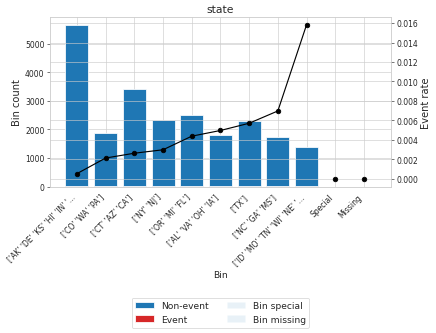

restaurant_type IV = 0.139446


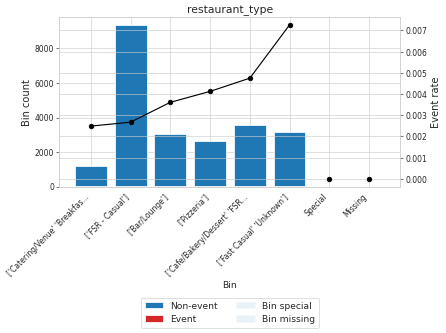

parent_market_segment IV = 0.0


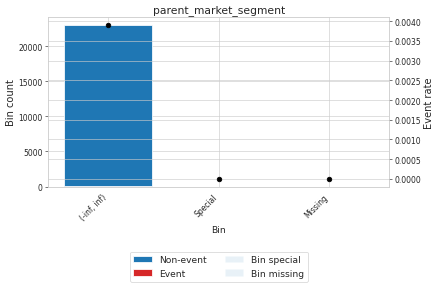

account_restaurant_category IV = 0.013435


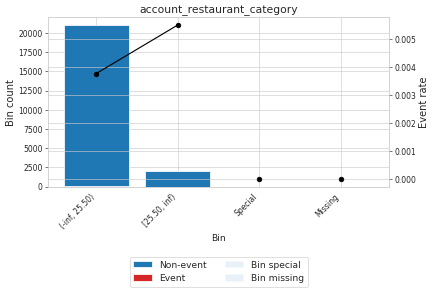

days_delta_first_obs IV = 0.10439


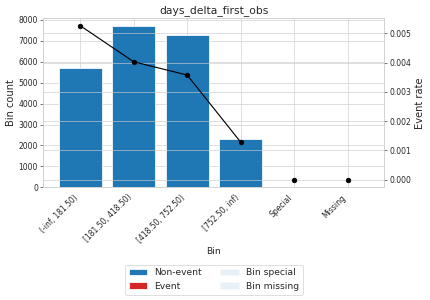

days_with_toast IV = 0.071259


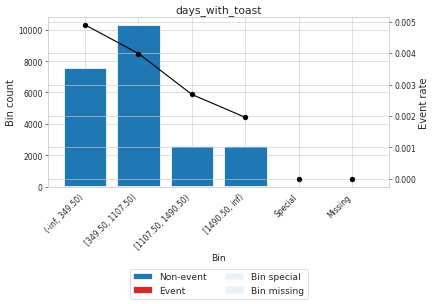

months_with_toast IV = 0.061839


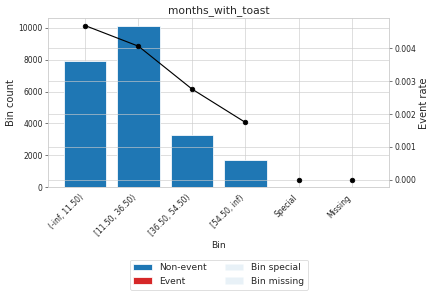

has_oo_mod IV = 0.011105


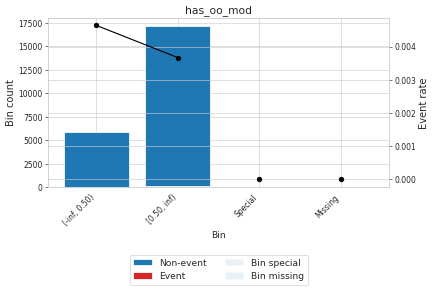

has_gc_mod IV = 0.020937


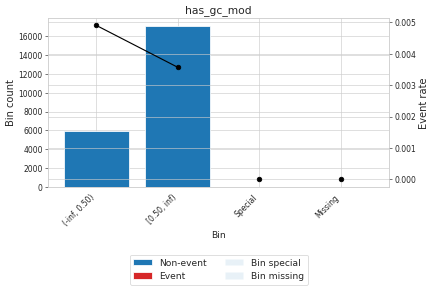

noprocessing_last_90d IV = 0.0


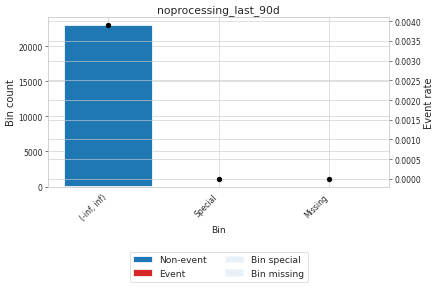

gpv_mean_90d IV = 0.627499


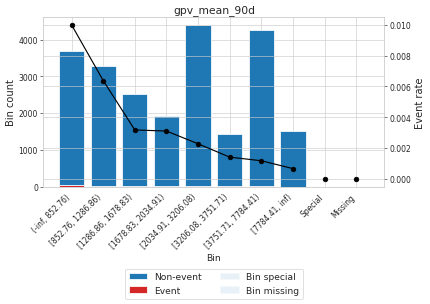

gpv_mean_28d IV = 0.761162


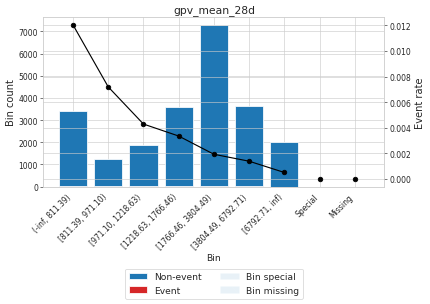

gpv_median_28d IV = 0.908602


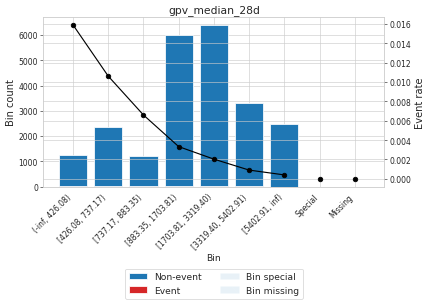

gpv_cv_90d IV = 0.36175


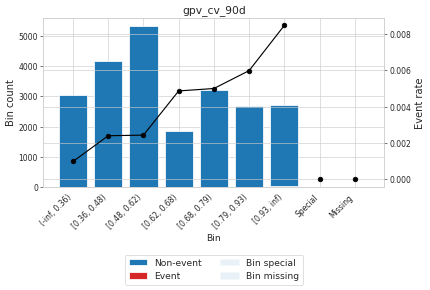

log_gpv_std_90d IV = 0.324883


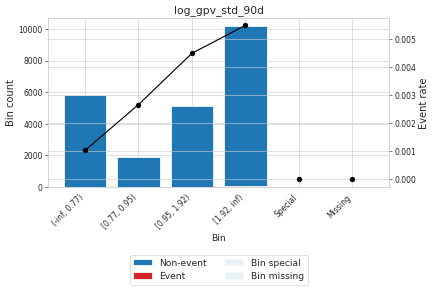

gpv_median_28d_mean_90d_diff IV = 0.16517


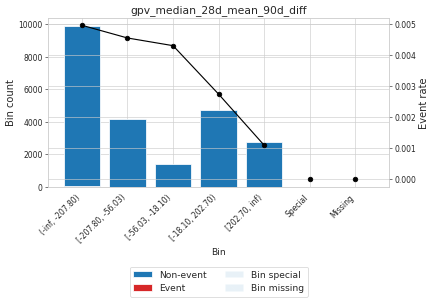

gpv_median_28d_median_84d_diff IV = 0.315633


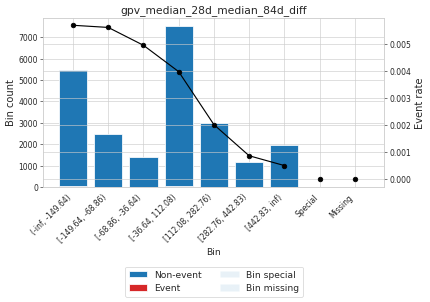

gpv_median_28d_28ddiff IV = 0.151278


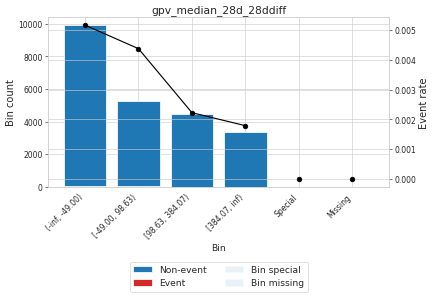

gpv_median_28d_84ddiff IV = 0.245775


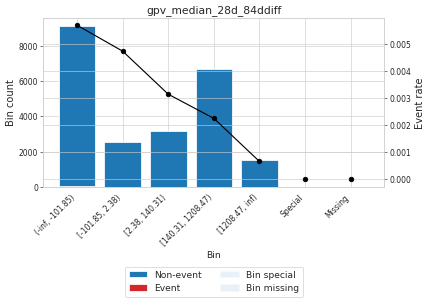

gpv_per_hour_median_28d IV = 0.797204


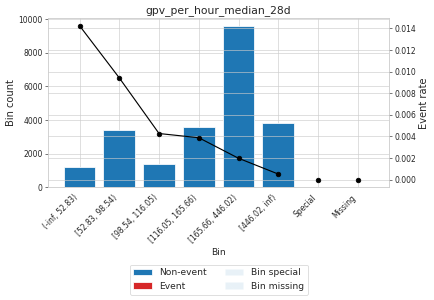

gpv_per_hour_median_28d_28ddiff IV = 0.183187


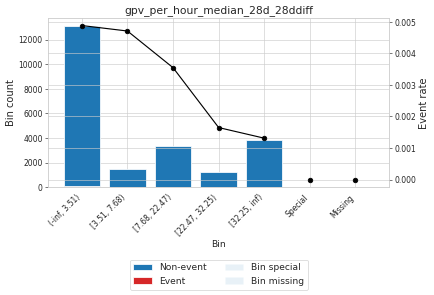

days_no_gpv_90d IV = 0.233697


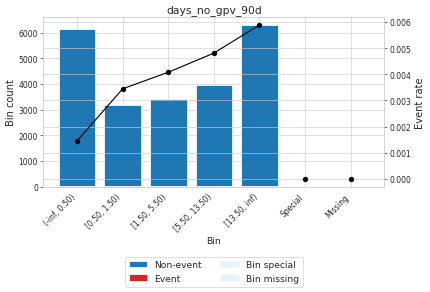

days_no_gpv_28d IV = 0.306995


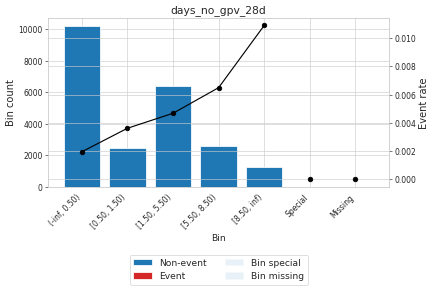

days_no_gpv_28d_28ddiff IV = 0.404911


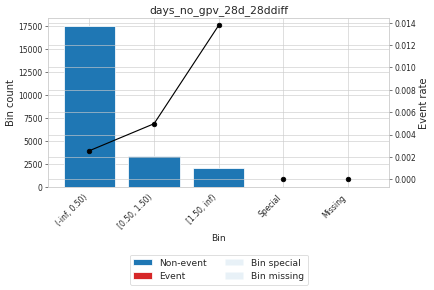

tx_hours_mean_14d IV = 0.559987


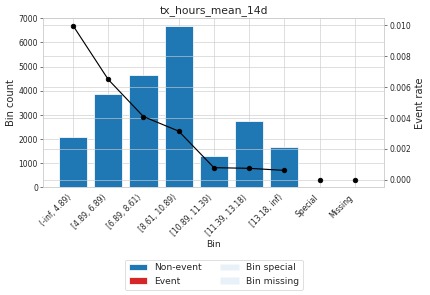

tx_hours_median_14d IV = 0.488796


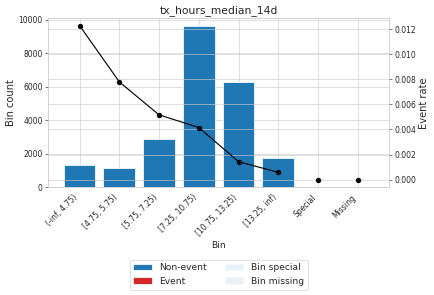

tx_hours_median_28d IV = 0.284213


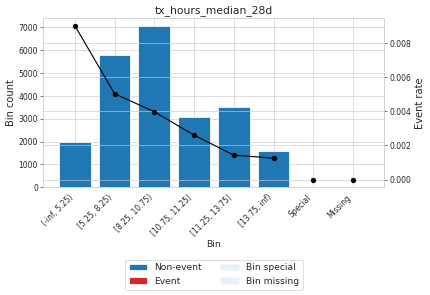

tx_hours_median_28d_28ddiff IV = 0.159025


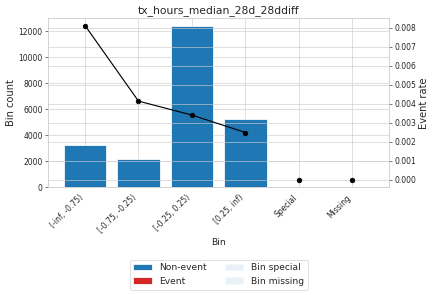

live_online_ordering_module_count IV = 0.011105


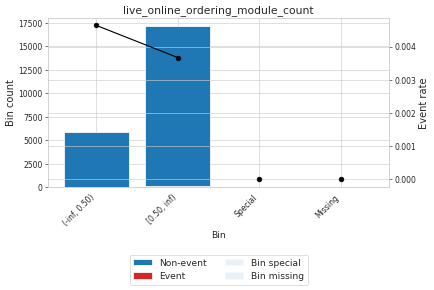

live_saas_mrr IV = 0.100719


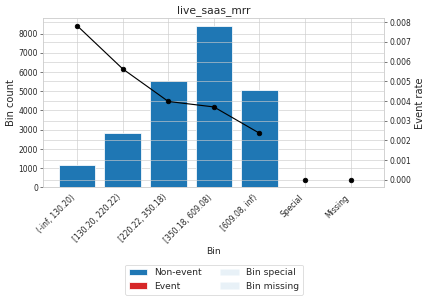

live_saas_module_count IV = 0.083222


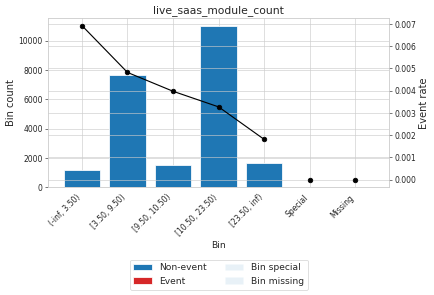

live_gift_card_module_count IV = 0.020937


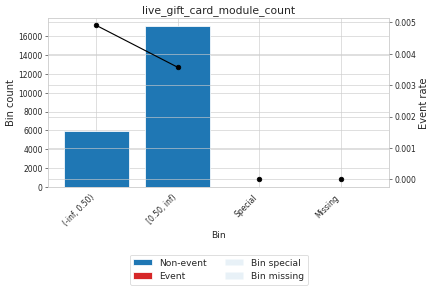

total_no_of_orders_30d IV = 0.848981


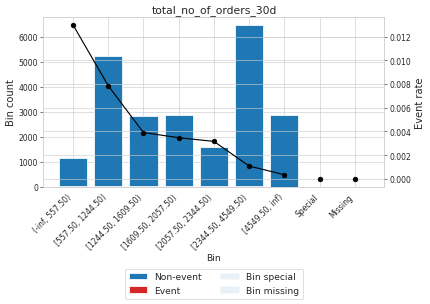

median_no_of_orders_180d IV = 0.716594


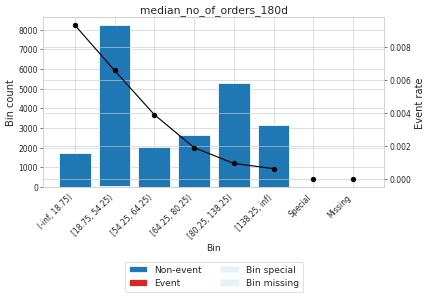

std_orders_180d IV = 0.184254


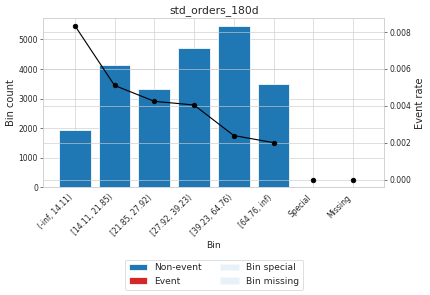

gmv_sum_30d IV = 0.828111


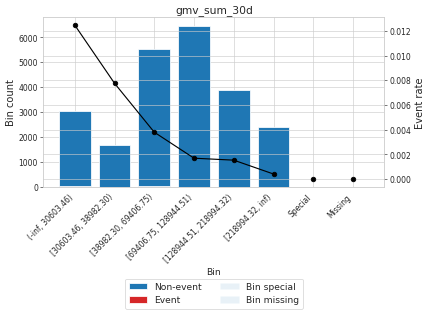

total_size_orders_90 IV = 0.646799


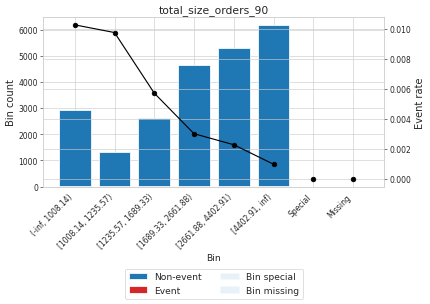

GMV_90D_Percent_Change IV = 0.110677


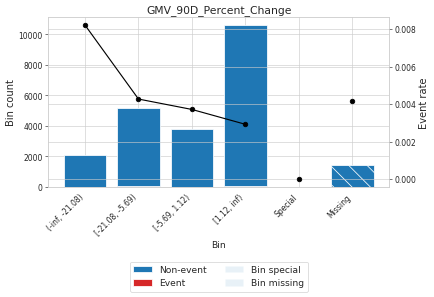

GMV_YoY_90D_Percent_Change IV = 0.407317


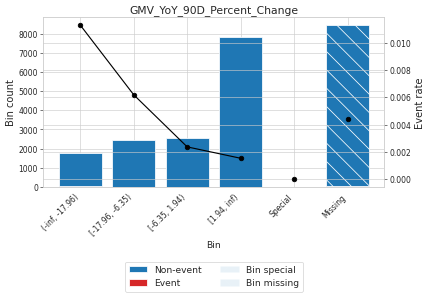

gpv_mean_365d IV = 0.625937


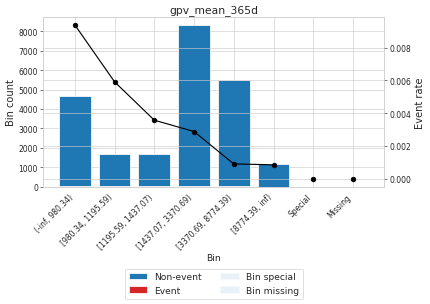

gpv_mean_180d IV = 0.702158


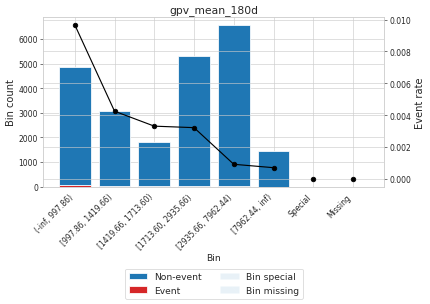

gpv_cv_180d IV = 0.372958


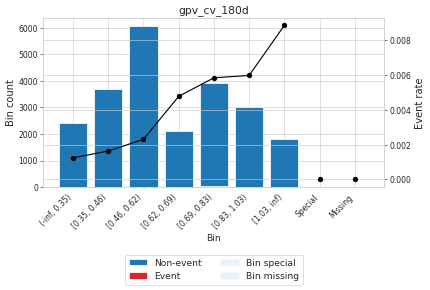

gpv_median_84d IV = 0.792656


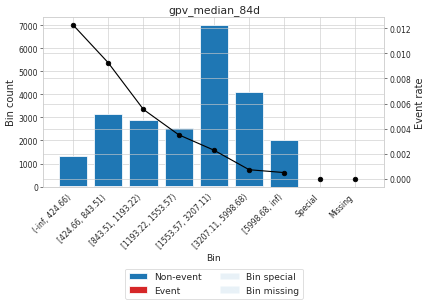

gpv_median_180d IV = 0.758349


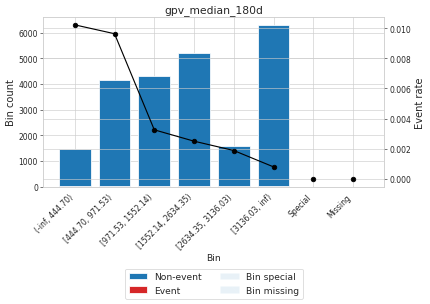

gpv_median_28d_median_180d_diff IV = 0.26641


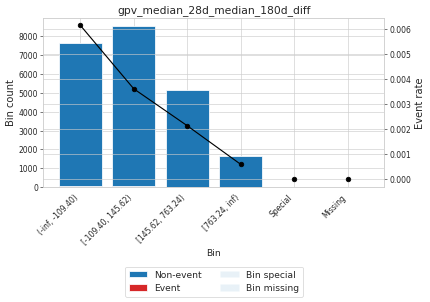

gpv_per_hour IV = 0.771134


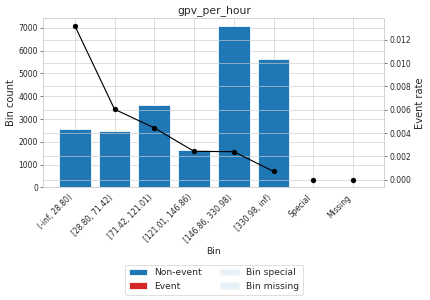

noprocessing_last_180d IV = 0.0


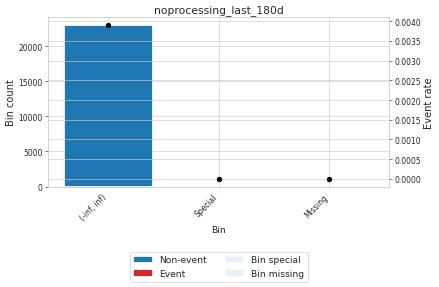

In [28]:
plt.rcParams['figure.figsize'] = [8, 4]
plt.rcParams['figure.dpi'] = 55 # 200 e.g. is really fine, but slower
bin_table = pd.DataFrame()
# feature_type = {'x1':"numerical"}
for feature in feature_dict:
    optb = OptimalBinning(name=feature, dtype=feature_dict[feature], min_prebin_size=0.05,solver="cp",monotonic_trend='auto_asc_desc')
    optb.fit(X_train[feature], y_train)
    woe_var = feature + '_woe'
    # Add WoE variables to the data
    df_train[woe_var] = optb.transform(df_train[feature], metric="woe")
    df_test[woe_var] = optb.transform(df_test[feature], metric="woe")
    df_val[woe_var] = optb.transform(df_val[feature], metric="woe")

    binning_table = optb.binning_table
    table = binning_table.build() 
    
    #Vizualize
    print(feature, "IV =", round(table.loc[['Totals']].IV[0],6))
    binning_table.plot(metric="event_rate",style='bin',show_bin_labels=True)
    
    table.reset_index(inplace=True)
    table['FeatureName'] = feature
    bin_table = pd.concat([bin_table, table])

bin_table=bin_table.reset_index()
bin_table.drop(columns='level_0',inplace=True)
bin_table.rename(columns = {'index':'Bin_Num'},inplace=True)

In [29]:
totals = bin_table[bin_table['Bin_Num'] == 'Totals']
totals.sort_values(by='IV', ascending=False, na_position='first',inplace=True)
totals[['FeatureName','IV']].to_excel('VariablesSummary.xlsx',index=False)
bin_table.to_csv('BinTable.csv',index=False)

In [30]:
df_train.columns

Index(['rid', 'dt', 'label_60', 'flag_ge50_3d_over_7d', 'state',
       'parent_market_segment', 'restaurant_type',
       'account_restaurant_category', 'days_delta_first_obs',
       'first_loan_date',
       ...
       'GMV_90D_Percent_Change_woe', 'GMV_YoY_90D_Percent_Change_woe',
       'gpv_mean_365d_woe', 'gpv_mean_180d_woe', 'gpv_cv_180d_woe',
       'gpv_median_84d_woe', 'gpv_median_180d_woe',
       'gpv_median_28d_median_180d_diff_woe', 'gpv_per_hour_woe',
       'noprocessing_last_180d_woe'],
      dtype='object', length=116)

In [31]:
y_train.value_counts()

0.0    22921
1.0       90
Name: fpf, dtype: int64

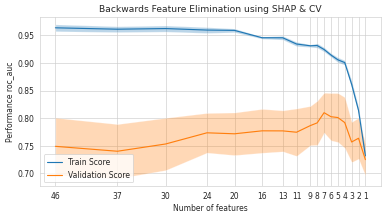

In [32]:
list_woe = [x for x in df_train.columns if x[-3:]=='woe']
remove_list = ['day_of_year_woe', 'month_woe', 'quarter_woe','state_woe',]
list_woe = [x for x in list_woe if x not in remove_list]

clf = GradientBoostingClassifier(random_state=42)

grid = {
    "n_estimators": [40,50, 100, 200, 500], #The number of boosting stages to perform
    "max_leaf_nodes": [2, 5, 10, 20], # Grow trees with max_leaf_nodes in best-first fashion.
    "learning_rate": [0.01,0.1,0.5,1], #Learning rate shrinks the contribution of each tree by learning_rate
    "min_samples_leaf":[0.02,0.05], #The minimum number of samples required to be at a leaf node.
}

# grid_search = HalvingGridSearchCV(estimator=clf, param_grid=grid, n_jobs=-1, cv=3, \
#                                   scoring='roc_auc',error_score=0,random_state=42, refit=True)
# grid_search.fit(df_train[list_woe], y_train)


clf.fit(df_train[list_woe], y_train)

shap_elimination = ShapRFECV(model=clf, step=0.2, cv=5, scoring='roc_auc', n_jobs=-1)
report = shap_elimination.fit_compute(df_train[list_woe], y_train,check_additivity=False)
performance_plot = shap_elimination.plot()

In [33]:
report[report['num_features']<20][['num_features', 'features_set', 'train_metric_mean','val_metric_mean']]

,num_features,features_set,train_metric_mean,val_metric_mean
6,16,"[restaurant_type_woe, gpv_mean_90d_woe, gpv_median_28d_woe, log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, days_no_gpv_90d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, total_no_of_orders_30d_woe, median_no_of_orders_180d_woe, gmv_sum_30d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe, gpv_median_180d_woe, gpv_per_hour_woe]",0.945535,0.777164
7,13,"[restaurant_type_woe, gpv_mean_90d_woe, gpv_median_28d_woe, log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, total_no_of_orders_30d_woe, median_no_of_orders_180d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe, gpv_per_hour_woe]",0.945465,0.777060
8,11,"[gpv_mean_90d_woe, gpv_median_28d_woe, log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, total_no_of_orders_30d_woe, median_no_of_orders_180d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.934185,0.774631
9,9,"[gpv_median_28d_woe, log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, total_no_of_orders_30d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.930973,0.786599
10,8,"[log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, total_no_of_orders_30d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.931481,0.791550
11,7,"[log_gpv_std_90d_woe, gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.924289,0.809983
12,6,"[gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, tx_hours_median_28d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.914284,0.802706
13,5,"[gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, GMV_YoY_90D_Percent_Change_woe, gpv_mean_180d_woe]",0.905623,0.801194
14,4,"[gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe, GMV_YoY_90D_Percent_Change_woe]",0.900602,0.792099
15,3,"[gpv_median_28d_mean_90d_diff_woe, gpv_per_hour_median_28d_woe, tx_hours_mean_14d_woe]",0.861399,0.756938


In [34]:

vars_cat = [
    # 'state',
            'account_restaurant_category',
            'parent_market_segment',
           ]
vars_noorder = ['day_of_year']
vars_asc = ['days_no_gpv_28d',
            'days_no_gpv_90d',

           'gpv_cv_90d',
            
           ]
vars_des =[  'has_gc_mod',
           # 'has_oo_mod',
           'gpv_mean_28d',
           'gpv_mean_90d',
           'gpv_median_28d_28ddiff',
           'gpv_per_hour_median_28d',
           'tx_hours_median_14d',
           'tx_hours_median_28d_28ddiff',
            'GMV_YoY_90D_Percent_Change',
           'median_no_of_orders_180d',
           'gpv_median_28d_median_84d_diff',
           'total_size_orders_90',
           'gmv_sum_30d',
           
          ]
pd_features = vars_cat + vars_noorder + vars_asc + vars_des
var_monotone = [0] * len(vars_cat + vars_noorder) +[1] * len(vars_asc) + [-1] * len(vars_des)
df_train_encoded = df_train.copy()
df_test_encoded = df_test.copy()
df_val_encoded = df_val.copy()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
# df_train_encoded[vars_cat] = oe.fit_transform(df_train_encoded[vars_cat])
# df_test_encoded[vars_cat] = oe.fit_transform(df_test_encoded[vars_cat])
# df_val_encoded[vars_cat] = oe.fit_transform(df_val_encoded[vars_cat])

In [35]:
df = pd.concat([df_train,df_test,df_val])
df[pd_features].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38889 entries, 4152 to 8296
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   account_restaurant_category     38889 non-null  int64  
 1   parent_market_segment           38889 non-null  int64  
 2   day_of_year                     38889 non-null  int64  
 3   days_no_gpv_28d                 38889 non-null  float64
 4   days_no_gpv_90d                 38889 non-null  float64
 5   gpv_cv_90d                      38889 non-null  float64
 6   has_gc_mod                      38889 non-null  int64  
 7   gpv_mean_28d                    38889 non-null  float64
 8   gpv_mean_90d                    38889 non-null  float64
 9   gpv_median_28d_28ddiff          38889 non-null  float64
 10  gpv_per_hour_median_28d         38889 non-null  float64
 11  tx_hours_median_14d             38889 non-null  float64
 12  tx_hours_median_28d_28ddiff   

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
import lightgbm as lgb


def bayes_parameter_opt_lgb(X, y, categorical_feats, init_round=15, opt_round=25, n_folds=3, random_seed=137, n_estimators=1000, output_process=False,monotonic_contraints=None):
    import warnings
    warnings.filterwarnings("ignore")
    # prepare data
    train_data = lgb.Dataset(data=X, label=y, categorical_feature = categorical_feats, free_raw_data=False)
    # parameters
    def lgb_eval(num_leaves, min_data_in_leaf, learning_rate, min_sum_hessian_in_leaf, feature_fraction, bagging_fraction, max_depth, lambda_l1, lambda_l2, min_split_gain, min_child_weight):
        
        params = {'objective':'binary', 'num_iterations': n_estimators, 'learning_rate':learning_rate,
        'boost_from_average': False, 'is_unbalance': False, 'early_stopping_round':100, 'verbose':-1, 'metric':'auc', 'monotone_constraints' : monotonic_contraints}
        
        params["num_leaves"] = int(round(num_leaves))
        params['feature_fraction'] = max(min(feature_fraction, 1), 0)
        params['bagging_fraction'] = max(min(bagging_fraction, 1), 0)
        params['max_depth'] = int(round(max_depth))
        params['lambda_l1'] = max(lambda_l1, 0)
        params['lambda_l2'] = max(lambda_l2, 0)
        params['min_split_gain'] = min_split_gain
        params['min_child_weight'] = min_child_weight
        #cv_result = lgb.cv(params, train_data, nfold=n_folds, seed=random_seed, stratified=True, verbose_eval=200, metrics=['auc'])
        cv_result = lgb.cv(params, train_data, nfold=n_folds, seed=random_seed, stratified=True, metrics=['auc'])
        # print(cv_result)
        return max(cv_result['auc-mean'])
        # return 1
 


    # Bounded region of parameter space
    bounds_LGB = {
        'num_leaves': (15, 45), 
        'min_data_in_leaf': (5, 20),  
        'learning_rate': (0.01, 0.3),
        'min_sum_hessian_in_leaf': (0.00001, 0.01),    
        'feature_fraction': (0.05, 0.9),
        'bagging_fraction': (0.8, 1),
        'max_depth':(5,12),
        'lambda_l1': (0, 5.0), 
        'lambda_l2': (0, 5.0), 
        'min_split_gain': (0.001, 0.5),              
        'min_child_weight': (5, 50),
    }
    
    lgbBO = BayesianOptimization(lgb_eval, bounds_LGB, random_state=42)
    # optimize
    lgbBO.maximize(init_points=init_round, n_iter=opt_round)
    
    # output optimization process
    if output_process==True: lgbBO.points_to_csv("bayes_opt_result.csv")
    
    # return best parameters
    return lgbBO.max['target'], lgbBO.max['params']

# Function to split long description into smaller chunks in multiple lines
def split_text_newline(text,span=15):
    words = text.split(' ')
    words_list = [' '.join(words[i:i+span]) for i in range(0, len(words), span)]
    text = '\n '.join(words_list)
    return text

In [37]:
# from LGBMBayesianOptimization import bayes_parameter_opt_lgb
opt_res, opt_params = bayes_parameter_opt_lgb(df_train_encoded[pd_features], y_train, categorical_feats = vars_cat, init_round=15, \
                                              opt_round=15, n_folds=3, random_seed=42, n_estimators=1000, monotonic_contraints = var_monotone)
opt_res, opt_params

|   iter    |  target   | baggin... | featur... | lambda_l1 | lambda_l2 | learni... | max_depth | min_ch... | min_da... | min_sp... | min_su... | num_le... |
-------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | 0.5       | 0.8749    | 0.8581    | 3.66      | 2.993     | 0.05525   | 6.092     | 7.614     | 17.99     | 0.301     | 0.007084  | 15.62     |
| 2         | 0.5       | 0.994     | 0.7576    | 1.062     | 0.9091    | 0.06319   | 7.13      | 28.61     | 11.48     | 0.1463    | 0.006122  | 19.18     |
| 3         | 0.5       | 0.8584    | 0.3614    | 2.28      | 3.926     | 0.06791   | 8.6       | 31.66     | 5.697     | 0.3042    | 0.001714  | 16.95     |
| 4         | 0.5       | 0.9898    | 0.8708    | 4.042     | 1.523     | 0.03832   | 9.79      | 24.81     | 6.831     | 0.2481    | 0.0003535 | 42.28     |
| 5         | 0.5       | 0.8518    | 0.6131    | 1.

(0.5,
 {'bagging_fraction': 0.8749080237694725,
  'feature_fraction': 0.8581071604484287,
  'lambda_l1': 3.6599697090570253,
  'lambda_l2': 2.993292420985183,
  'learning_rate': 0.055245405728306586,
  'max_depth': 6.091961642353418,
  'min_child_weight': 7.613762547568976,
  'min_data_in_leaf': 17.99264218662403,
  'min_split_gain': 0.3009563908598612,
  'min_sum_hessian_in_leaf': 0.007083645052182495,
  'num_leaves': 15.617534828874074})

In [38]:
param_dict = opt_params
seed=42

param_lgb = {
        'num_leaves': int(param_dict['num_leaves']),
        'min_data_in_leaf': int(param_dict['min_data_in_leaf']), 
        'learning_rate':param_dict['learning_rate'],
        'min_sum_hessian_in_leaf': param_dict['min_sum_hessian_in_leaf'],
        'bagging_fraction': param_dict['bagging_fraction'], 
        'feature_fraction': param_dict['feature_fraction'],
        'lambda_l1': param_dict['lambda_l1'],
        'lambda_l2': param_dict['lambda_l2'],
        'min_gain_to_split': param_dict['min_split_gain'],
        'max_depth': int(param_dict['max_depth']), 
        'save_binary': True,
        'seed': seed,
        'feature_fraction_seed': seed,
        'bagging_seed': seed,
        'drop_seed': seed,
        'data_random_seed': seed,
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'metric': 'auc',
        'is_unbalance': False,
        'boost_from_average': False,
        'monotone_constraints': var_monotone
    }

model = lgb.LGBMClassifier(importance_type='gain', **param_lgb)

model.fit(df_train_encoded[pd_features], y_train)

LGBMClassifier(bagging_fraction=0.8749080237694725, bagging_seed=42,
               boost_from_average=False, data_random_seed=42, drop_seed=42,
               feature_fraction=0.8581071604484287, feature_fraction_seed=42,
               importance_type='gain', is_unbalance=False,
               lambda_l1=3.6599697090570253, lambda_l2=2.993292420985183,
               learning_rate=0.055245405728306586, max_depth=6, metric='auc',
               min_data_in_leaf=17, min_gain_to_split=0.3009563908598612,
               min_sum_hessian_in_leaf=0.007083645052182495,
               monotone_constraints=[0, 0, 0, 1, 1, 1, -1, -1, -1, -1, -1, -1,
                                     -1, -1, -1, -1, -1, -1],
               num_leaves=15, objective='binary', save_binary=True, seed=42,
               verbose=-1)

In [39]:
# make prediction on the trainin and test set
df_train_encoded['y_pred'] = model.predict_proba(df_train_encoded[pd_features])[:,1] 
print(f"training set AUC: {roc_auc_score(y_train, df_train_encoded['y_pred']).round(3)}")

df_test_encoded['y_pred'] = model.predict_proba(df_test_encoded[pd_features])[:,1] 
print(f"test set AUC: {roc_auc_score(y_test, df_test_encoded['y_pred']).round (3)}")

df_val_encoded['y_pred'] = model.predict_proba(df_val_encoded[pd_features])[:,1] 
print(f"Val set AUC: {roc_auc_score(df_val['fpf'], df_val_encoded['y_pred']).round (3)}")

training set AUC: 0.5
test set AUC: 0.5
Val set AUC: 0.5


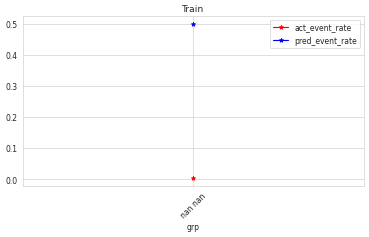

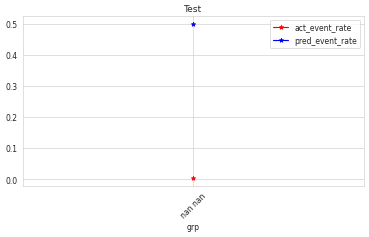

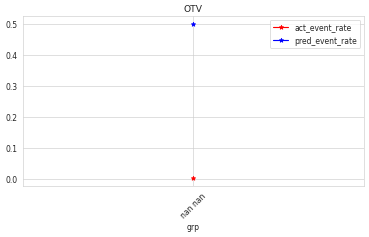

In [40]:
ror_train = exp_vs_act(df_train_encoded,'y_pred','fpf','Train')
ror_test = exp_vs_act(df_test_encoded,'y_pred','fpf','Test')
ror_val = exp_vs_act(df_val_encoded,'y_pred','fpf','OTV')

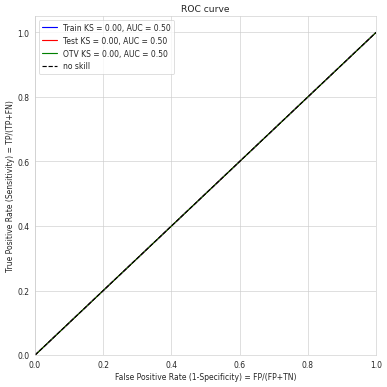

In [41]:
# from functions import plot_auc3
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc2(ax, y_train, df_train['y_pred'], y_test, df_test['y_pred'])
plot_auc3(ax, y_train, df_train_encoded['y_pred'], y_test, df_test_encoded['y_pred'], df_val_encoded.fpf, df_val_encoded['y_pred'])

In [42]:
df_train_encoded1 = df_train_encoded.dropna(subset=['base_model_pd'])
mask = df_train_encoded['base_model_pd'].notna() 
# Apply the mask to both df_train_encoded and y_train
df_train_encoded1 = df_train_encoded[mask]
y_train1 = y_train[mask]

In [43]:
df_test_encoded1 = df_test_encoded.dropna(subset=['base_model_pd'])
mask = df_test_encoded['base_model_pd'].notna() 
# Apply the mask to both df_train_encoded and y_train
df_test_encoded1 = df_test_encoded[mask]
y_test1 = y_test[mask]

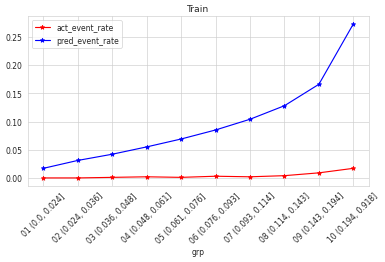

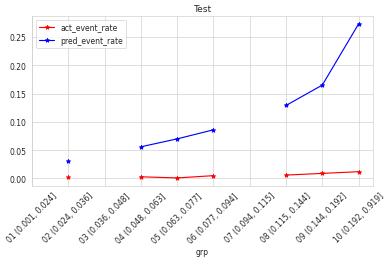

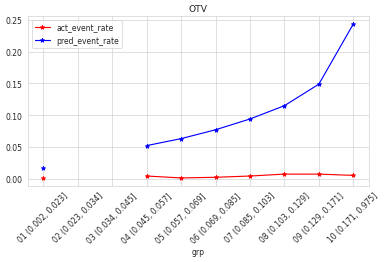

In [44]:
ror_train = exp_vs_act(df_train_encoded1,'base_model_pd','fpf','Train')
ror_test = exp_vs_act(df_test_encoded1,'base_model_pd','fpf','Test')
ror_val = exp_vs_act(df_val_encoded,'base_model_pd','fpf','OTV')

In [45]:
def plot_auc2(ax, y_train, y_train_pred, y_test, y_test_pred, title1='', title2='', th=0.5):
    from sklearn.metrics import roc_curve, auc, accuracy_score

    # Convert probabilities to binary labels based on threshold
    y_train_pred_labels = (y_train_pred > th).astype(int)
    y_test_pred_labels  = (y_test_pred > th).astype(int)

    # Compute ROC curve and AUC for train set
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
    ks_train = max(tpr_train - fpr_train)
    roc_auc_train = auc(fpr_train, tpr_train)
    acc_train = accuracy_score(y_train, y_train_pred_labels)

    # Compute ROC curve and AUC for test set
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
    ks_test = max(tpr_test - fpr_test)
    roc_auc_test = auc(fpr_test, tpr_test)
    acc_test = accuracy_score(y_test, y_test_pred_labels)

    # Plot ROC curves
    ax.plot(fpr_train, tpr_train, color="blue", label=f"{title1}: KS={ks_train:.2f}, AUC={roc_auc_train:.2f}")
    ax.plot(fpr_test, tpr_test, color="red", label=f"{title2}: KS={ks_test:.2f}, AUC={roc_auc_test:.2f}")
    ax.plot([0, 1], [0, 1], 'k--', label="No Skill")

    # Formatting
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1-Specificity) = FP/(FP+TN)')
    ax.set_ylabel('True Positive Rate (Sensitivity) = TP/(TP+FN)')
    ax.set_title('ROC Curve')
    ax.legend()

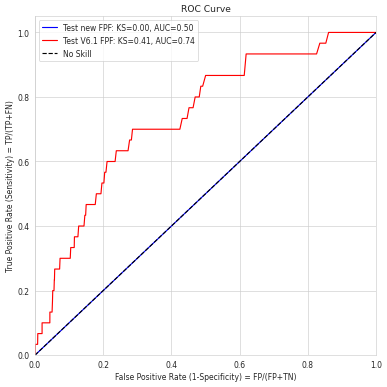

In [46]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc3(ax, y_train1, df_train_encoded1['base_model_pd'], y_test1, df_test_encoded1['base_model_pd'], df_val_encoded.label_60, df_val_encoded['base_model_pd'])
plot_auc2(ax, y_test, df_test_encoded['y_pred'], y_test1, df_test_encoded1['base_model_pd'], 'Test new FPF','Test V6.1 FPF' ,th=0.5)

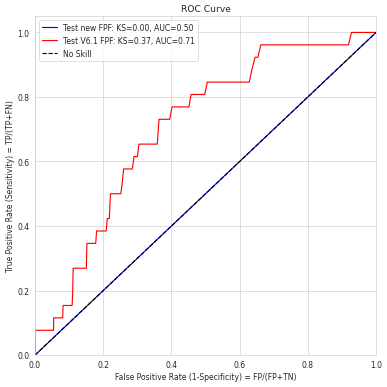

In [47]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc3(ax, y_train1, df_train_encoded1['base_model_pd'], y_test1, df_test_encoded1['base_model_pd'], df_val_encoded.label_60, df_val_encoded['base_model_pd'])
plot_auc2(ax, df_val_encoded.fpf, df_val_encoded['y_pred'], df_val_encoded.fpf, df_val_encoded['base_model_pd'], 'Test new FPF','Test V6.1 FPF' ,th=0.5)

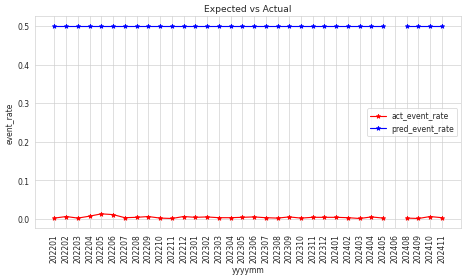

In [48]:
df_train_encoded['yyyymm'] = df_train_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_test_encoded['yyyymm'] = df_test_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_val_encoded['yyyymm'] = df_val_encoded['dt'].astype(str).str[:7].str.replace('-', '')

df = pd.concat([df_train_encoded,df_test_encoded,df_val_encoded])
target = 'fpf'
score = 'y_pred'
date = 'yyyymm'
exp_vs_act_date(df,score,date,target)

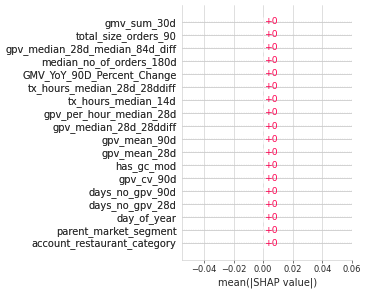

In [49]:
explainer = shap.Explainer(model, df_val_encoded[pd_features], feature_names=[pd_features])
shap_values = explainer(df_val_encoded[pd_features],check_additivity=False)
fig = plt.figure()
shap.plots.bar(shap_values, max_display=20,show = False)
plt.gcf().set_size_inches(4,6)
plt.show()

In [50]:
feature_names = shap_values.feature_names
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
vals = np.abs(shap_df.values).mean(0)
shap_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name', 'feature_importance_vals'])
shap_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)

In [51]:
shap_importance['%importance'] = round((shap_importance['feature_importance_vals']/shap_importance['feature_importance_vals'].sum()),2)
shap_importance

,col_name,feature_importance_vals,%importance
0,account_restaurant_category,0.0,NaN
1,parent_market_segment,0.0,NaN
2,day_of_year,0.0,NaN
3,days_no_gpv_28d,0.0,NaN
4,days_no_gpv_90d,0.0,NaN
5,gpv_cv_90d,0.0,NaN
6,has_gc_mod,0.0,NaN
7,gpv_mean_28d,0.0,NaN
8,gpv_mean_90d,0.0,NaN
9,gpv_median_28d_28ddiff,0.0,NaN


In [52]:
# Plot feature importance
lgb.plot_importance(model, importance_type='gain', max_num_features=20)  # You can adjust max_num_features as needed
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

In [ ]:
print(f"AUC: {roc_auc_score(df_val_encoded['fpf'], df_val_encoded['y_pred']).round (3)}")
print()
print('Difference between average prediction and true default rate')
print(f"Diff in mean pred: {(df_val_encoded['y_pred'].mean() - df_val_encoded['fpf'].mean()).round(3)}")
print(f"Diff in std pred: {(df_val_encoded['y_pred'].std() - df_val_encoded['fpf'].std())}")

In [ ]:
from sklearn.inspection import (partial_dependence, PartialDependenceDisplay)
n_cols = 1
n_rows = int(len(df_train_encoded[pd_features].columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(6, 40))
tree_disp = PartialDependenceDisplay.from_estimator(model, df_train_encoded[pd_features], df_train_encoded[pd_features].columns, ax=ax, n_cols=n_cols)
for i in range(len(df_train_encoded[pd_features].columns)):
    ylim_min=tree_disp.lines_[i].get_ydata().min()
    ylim_max=tree_disp.lines_[i].get_ydata().max()
    q=tree_disp.axes_[i].set_ylim(ylim_min*.9,ylim_max*1.1)
fig.suptitle('')
fig.tight_layout()